# Trustworthy recidivism forecasting — self-contained submission

This notebook follows the familiar machine-learning workflow: **load data → explore the training data → choose and engineer eligible features → check leakage → train → evaluate → explain → test stability and fairness → recommend**. The three NIJ source CSVs are compressed in the notebook's metadata and loaded by a short cell, with SHA-256 checks. This `.ipynb` can stand alone as the analysis file; the course presentation and app are separate deliverables. It does not import code from `src/` or `scripts/`, run shell commands, or read saved models and result tables. It still requires installed third-party Python packages and TabICL's checkpoint, which TabICL can obtain through its normal package mechanism.

To rerun in a fresh Python environment, save the notebook locally and open it from its folder. Install `numpy`, `pandas`, `scikit-learn==1.7.2`, `xgboost`, `tabicl==2.2.0`, `torch`, `shap`, `lime`, `XPER==0.0.92`, `statsmodels`, `matplotlib` and `ipykernel`, then use **Run All**. A first TabICL checkpoint download may require internet access; CUDA speeds up its repeated fits.

**Client and decision.** A community-supervision software vendor is considering a voluntary re-entry support offer to the highest-risk 20% of people at supervision start. This is a retrospective course analysis, not an operationally validated tool. Our target is cumulative new arrest within three years. NIJ's challenge used conditional annual forecasts, so these results are not leaderboard-comparable.

**Reading map.** Each section states its question, shows the code that produces the result, and interprets the result. The training partition is the official NIJ release; the evaluation partition is excluded from fitting, although its labels were inspected during project development. Treat all evaluation comparisons as exploratory.

In [1]:
from pathlib import Path
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss, r2_score
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBClassifier
import torch

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore', message="'penalty' was deprecated", category=FutureWarning)
print('Python dependencies loaded; CUDA available:', torch.cuda.is_available())

Python dependencies loaded; CUDA available: True


## 1. Load the dataset and define the prediction problem

The three original NIJ CSV inputs are embedded below as compressed data. The first is the full released dataset; the two earlier releases let us independently verify baseline fields and training outcomes. The outcome is cumulative new arrest within three years. We use the `Training_Sample` flag to recreate the official training and evaluation partitions; there is no new random split. The decision occurs at supervision start, before any future arrest or supervision activity.

In [2]:
import base64, hashlib, io, json, os, zlib

def find_embedded_data():
    # The build uses a temporary notebook; ordinary Run All finds this saved file.
    candidates = []
    build_source = os.environ.get('RECIDIVISM_NOTEBOOK_BUILD_SOURCE')
    if build_source:
        candidates.append(Path(build_source))
    candidates.extend([Path.cwd() / 'Recidivism_Project_Submission.ipynb',
                       *Path.cwd().glob('*.ipynb')])
    for path in dict.fromkeys(candidates):
        if not path.is_file():
            continue
        try:
            metadata = json.loads(path.read_text(encoding='utf-8')).get('metadata', {})
        except (OSError, ValueError):
            continue
        payload = metadata.get('recidivism_embedded_csvs')
        if payload and payload.get('format') == 'zlib+base64':
            return payload['files']
    raise FileNotFoundError('Save this notebook locally, then run it from its folder.')

EMBEDDED_CSVS = find_embedded_data()

def load_nij_csv(name):
    record = EMBEDDED_CSVS[name]
    data = zlib.decompress(base64.b64decode(record['zlib_base64']))
    assert hashlib.sha256(data).hexdigest() == record['sha256'], f'Dataset checksum mismatch: {name}'
    return pd.read_csv(io.BytesIO(data))

print('Three embedded NIJ CSVs found; each is SHA-256 checked when loaded.')

Three embedded NIJ CSVs found; each is SHA-256 checked when loaded.


In [3]:
TARGET = 'Recidivism_Within_3years'
raw = load_nij_csv('nij-challenge2021_full_dataset.csv')
assert raw.ID.is_unique and raw.ID.notna().all()
assert set(raw.Training_Sample.unique()) == {0, 1}
y_all = raw[TARGET].map({'Yes': 1, 'No': 0})
assert y_all.notna().all()
train_mask = raw.Training_Sample.eq(1)
train_rows = raw.loc[train_mask].reset_index(drop=True)
eval_rows = raw.loc[~train_mask].reset_index(drop=True)
y_train = y_all[train_mask].astype(int).reset_index(drop=True)
y_eval = y_all[~train_mask].astype(int).reset_index(drop=True)
audit_train = train_rows[['ID','Gender','Race']].copy()
audit_eval = eval_rows[['ID','Gender','Race']].copy()
display(pd.Series({'rows':len(raw),'columns':raw.shape[1],
                   'official_training_rows':len(train_rows),
                   'official_evaluation_rows':len(eval_rows),
                   'training_new_arrest_rate':y_train.mean()}))
display(train_rows[[TARGET,'Age_at_Release','Supervision_Risk_Score_First','Gang_Affiliated']].head())

rows                        25835.000000
columns                        54.000000
official_training_rows      18028.000000
official_evaluation_rows     7807.000000
training_new_arrest_rate        0.578045
dtype: float64

,Recidivism_Within_3years,Age_at_Release,Supervision_Risk_Score_First,Gang_Affiliated
0,No,43-47,3.0,No
1,Yes,33-37,6.0,No
2,Yes,48 or older,7.0,No
3,No,38-42,7.0,No
4,Yes,33-37,4.0,No


## 2. Explore the training data (EDA)

EDA is restricted to the training partition so choices about missingness, categories and feature transformations do not depend on evaluation outcomes. We inspect class balance, column types, missing values and category levels before modeling. Protected groups are shown here only to understand the data and later audit errors; they are excluded from scoring.

In [4]:
eda = train_rows.drop(columns=['ID','Training_Sample'])
display(pd.DataFrame({'outcome':["No new arrest","New arrest"],
                      'count':y_train.value_counts().sort_index().values,
                      'share':y_train.value_counts(normalize=True).sort_index().values}))
display(pd.Series({'numeric_columns':int(eda.select_dtypes(include='number').shape[1]),
                   'categorical_columns':int(eda.select_dtypes(exclude='number').shape[1]),
                   'duplicate_training_IDs':int(train_rows.ID.duplicated().sum())}))
missing_eda = train_rows.isna().mean().sort_values(ascending=False)
display(missing_eda.head(15).rename('missing_share').to_frame())
display(pd.DataFrame({'feature':['Age_at_Release','Supervision_Risk_Score_First',
                                 'Gang_Affiliated','Prison_Offense'],
                      'distinct_nonmissing':[train_rows[c].nunique(dropna=True) for c in
                                             ['Age_at_Release','Supervision_Risk_Score_First',
                                              'Gang_Affiliated','Prison_Offense']]}))

,outcome,count,share
0,No new arrest,7607,0.421955
1,New arrest,10421,0.578045


numeric_columns            9
categorical_columns       43
duplicate_training_IDs     0
dtype: int64

,missing_share
Avg_Days_per_DrugTest,0.236299
DrugTests_THC_Positive,0.201464
DrugTests_Cocaine_Positive,0.201464
DrugTests_Meth_Positive,0.201464
DrugTests_Other_Positive,0.201464
Prison_Offense,0.128744
Gang_Affiliated,0.122975
Supervision_Level_First,0.067229
Jobs_Per_Year,0.029621
Supervision_Risk_Score_First,0.018305


,feature,distinct_nonmissing
0,Age_at_Release,7
1,Supervision_Risk_Score_First,10
2,Gang_Affiliated,2
3,Prison_Offense,5


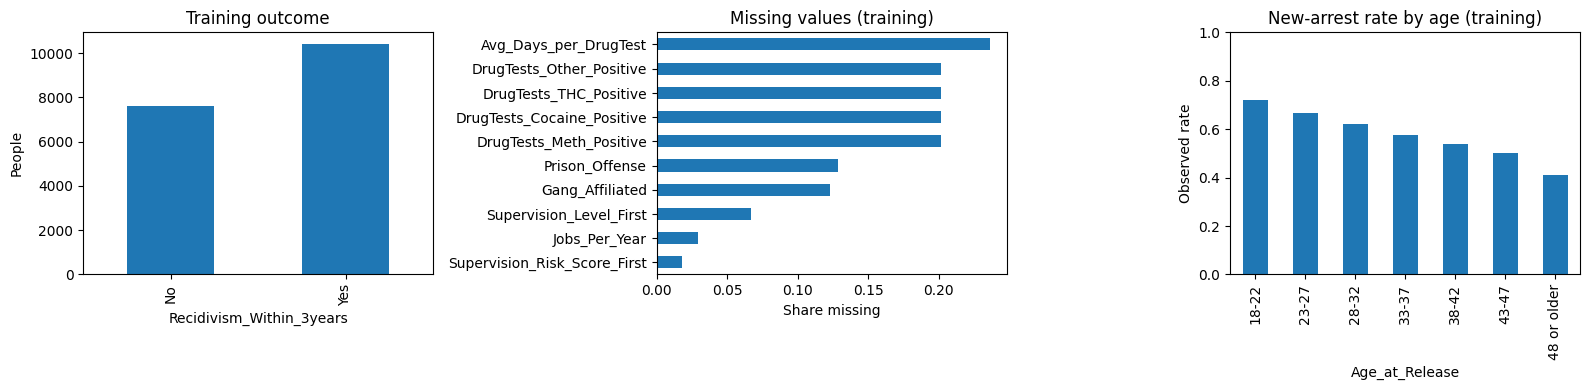

,new_arrest_rate,people
Age_at_Release,,
18-22,0.719,1454
23-27,0.667,3611
28-32,0.620,3449
33-37,0.575,2975
38-42,0.538,2040
43-47,0.503,1858
48 or older,0.412,2641


mean  size
Gender Race              
F      BLACK  0.445   743
       WHITE  0.461  1474
M      BLACK  0.600  9570
       WHITE  0.587  6241

In [5]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
y_train.map({0:'No',1:'Yes'}).value_counts().reindex(['No','Yes']).plot.bar(ax=axes[0],title='Training outcome')
missing_eda[missing_eda>0].head(10).sort_values().plot.barh(ax=axes[1],title='Missing values (training)')
age_order=['18-22','23-27','28-32','33-37','38-42','43-47','48 or older']
age_rates=train_rows.assign(outcome=y_train).groupby('Age_at_Release').outcome.agg(['mean','size']).reindex(age_order)
age_rates['mean'].plot.bar(ax=axes[2],title='New-arrest rate by age (training)')
axes[0].set(ylabel='People'); axes[1].set(xlabel='Share missing'); axes[2].set(ylabel='Observed rate',ylim=(0,1))
plt.tight_layout(); plt.show()
display(age_rates.rename(columns={'mean':'new_arrest_rate','size':'people'}).round(3))
display(train_rows.assign(outcome=y_train).groupby(['Gender','Race']).outcome.agg(['mean','size']).round(3))

The exploratory plots show why an accuracy score alone is insufficient: the outcome is common, arrest rates vary by age, and some baseline fields have structured missingness. These are associations, not causal effects. The evaluation partition remains untouched during the choices below.

## 3. Select and engineer eligible features

Only fields available in NIJ's first test release can enter a model. We keep 29 baseline fields and exclude ID, target, split flag, gender, race, geography and post-release supervision, employment or drug-test fields. `Gender` and `Race` stay in the audit tables. The feature list is explicit so a reader can see exactly what enters all three models.

In [6]:
FEATURES = [
    'Age_at_Release', 'Gang_Affiliated', 'Supervision_Risk_Score_First',
    'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense',
    'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd',
    'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property',
    'Prior_Arrest_Episodes_Drug', '_v1', 'Prior_Arrest_Episodes_DVCharges',
    'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony',
    'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol',
    'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug',
    '_v2', '_v3', '_v4', 'Prior_Revocations_Parole',
    'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed',
    'Condition_Other',
]
assert len(FEATURES) == 29 and set(FEATURES).issubset(raw.columns)
assert not set(FEATURES) & {'ID', 'Gender', 'Race', 'Residence_PUMA', TARGET, 'Training_Sample'}
assert not any(c.startswith('Recidivism_') for c in FEATURES)
X_train = train_rows[FEATURES].copy()
X_eval = eval_rows[FEATURES].copy()
display(pd.DataFrame({'feature':FEATURES,
                      'dtype':X_train.dtypes.astype(str).values,
                      'missing_train':X_train.isna().mean().values,
                      'levels_train':X_train.nunique(dropna=True).values}))
print('Model matrix:',X_train.shape,'training;',X_eval.shape,'evaluation')

,feature,dtype,missing_train,levels_train
0,Age_at_Release,str,0.000000,7
1,Gang_Affiliated,str,0.122975,2
2,Supervision_Risk_Score_First,float64,0.018305,10
3,Supervision_Level_First,str,0.067229,3
4,Education_Level,str,0.000000,3
5,Dependents,str,0.000000,4
6,Prison_Offense,str,0.128744,5
7,Prison_Years,str,0.000000,4
8,Prior_Arrest_Episodes_Felony,str,0.000000,11
9,Prior_Arrest_Episodes_Misd,str,0.000000,7


Model matrix: (18028, 29) training; (7807, 29) evaluation


## 4. Check leakage against the original releases

The full dataset was published after outcomes were known. We independently compare its baseline fields against the original training release and the first test release. We also verify the original training outcomes and disjoint IDs. These tests catch direct post-release fields and accidental row or label changes. They cannot establish the precise measurement timestamp of every nominally baseline field. The evaluation labels were used in later project development, so this is not an untouched research holdout.

In [7]:
first_test = load_nij_csv('nij-challenge2021_test_dataset_1.csv')
first_train = load_nij_csv('nij-challenge2021_training_dataset.csv')
assert set(FEATURES).issubset(first_test.columns)
assert set(first_test.ID) == set(audit_eval.ID)
assert set(first_train.ID) == set(audit_train.ID)
assert set(audit_train.ID).isdisjoint(audit_eval.ID)
indexed_full = raw.set_index('ID')
for release in (first_train, first_test):
    original = release.set_index('ID')[FEATURES].sort_index()
    current = indexed_full.loc[original.index, FEATURES]
    pd.testing.assert_frame_equal(original, current, check_dtype=False)
outcomes = [TARGET] + [f'Recidivism_Arrest_Year{i}' for i in (1,2,3)]
original_y = first_train.set_index('ID')[outcomes].sort_index()
pd.testing.assert_frame_equal(original_y, indexed_full.loc[original_y.index, outcomes], check_dtype=False)
missing = X_train.Gang_Affiliated.isna()
display(pd.Series({'released_features_verified':len(FEATURES), 'disjoint_IDs':True,
                   'training_outcomes_verified':True, 'gang_missing_rows':int(missing.sum()),
                   'women_among_gang_missing':float(audit_train.loc[missing,'Gender'].eq('F').mean())}))
print('Limitation: first-release availability does not prove that every assessment was measured before the decision.')

released_features_verified      29
disjoint_IDs                  True
training_outcomes_verified    True
gang_missing_rows             2217
women_among_gang_missing       1.0
dtype: object

Limitation: first-release availability does not prove that every assessment was measured before the decision.


### Missingness and protected-attribute proxies

`Gang_Affiliated` is missing for every woman and no man in the training set. A missingness indicator would reveal gender exactly even though Gender is excluded from model inputs. We use the **training mode** to fill missing categories, including for TabICL. Other correlations and proxies can still carry protected information; exclusion alone does not guarantee fairness.

In [8]:
display(pd.crosstab(audit_train.Gender, X_train.Gang_Affiliated.isna(), normalize='index'))
categorical = X_train.select_dtypes(exclude='number').columns
category_modes = X_train[categorical].mode().iloc[0]
tab_train, tab_eval = X_train.fillna(category_modes), X_eval.fillna(category_modes)
assert not tab_train[categorical].isna().any().any()
assert not tab_eval[categorical].isna().any().any()
print('Categorical missing values filled using training modes only.')

Gang_Affiliated,False,True
Gender,,
F,0.0,1.0
M,1.0,0.0


Categorical missing values filled using training modes only.


### How the modeling decisions were chosen

These are **recorded training-only experiments**, not searches rerun by this notebook. The tables are embedded here so no result files are needed to read the rationale. Higher AUC and lower Brier are better; scores from different validation protocols are not directly comparable.

**Logistic Regression: grid search and encoding.** Five-fold stratified CV tested 13 `C` values from 0.001 to 10, L1/L2 penalties and two encodings: **52 configurations / 260 fold fits**. Preprocessing was fitted inside each fold. Each row below is the best configuration *within that encoding*, not a controlled encoding-only experiment.

| Encoding | Best C, penalty | CV AUC | CV Brier | Decision |
|---|---|---:|---:|---|
| One-hot | 0.21544, L1 | 0.7324 | 0.2044 | Kept |
| Ordinal | 0.02154, L2 | 0.7315 | 0.2048 | Rejected |

Keep one-hot + L1 (`C=0.21544`, rounded to `0.2154` for the final fit): category-specific effects slightly outperformed a single ordinal slope. The difference is small, not proof of superiority; nearby regularization settings were also competitive.

**XGBoost: randomized search, then complexity checks.** The historical search used 60 draws × five stratified folds, selecting by AUC. It explored 300–1,399 trees, depth 2–6, learning rate 0.005–0.1, child weight 1–14, row/column sampling 0.6–1, and L1/L2/gamma regularization. The recorded winner was depth 2, 1,196 trees and learning rate 0.0188 (historically reported CV AUC ≈ 0.7343); the exact kept settings appear in the next cell. **The original search-results JSON/full trial log is not retained**, so that score is historical documentation, not independently verified trial evidence.

A later saved three-outer × three-inner-fold review compared 13 ordinal/one-hot configurations, depths 1–4 and shrinkage/regularization (**117 inner fits**). Selection minimized inner Brier, with AUC as tie-breaker. Selected comparisons below average the three saved inner-CV summaries:

| Candidate: encoding | Depth | Inner AUC | Inner Brier | Decision |
|---|---:|---:|---:|---|
| 0: ordinal | 2 | 0.7324 | 0.2043 | Kept |
| 2: ordinal | 2 | 0.7314 | 0.2047 | Rejected |
| 8: onehot | 2 | 0.7308 | 0.2048 | Rejected |
| 3: ordinal | 3 | 0.7296 | 0.2054 | Rejected |
| 4: ordinal | 4 | 0.7297 | 0.2053 | Rejected |

Keep candidate 0: it won all three outer selections. Candidates 2 and 8 have identical hyperparameters apart from encoding, and ordinal did slightly better. The shown depth-3/4 alternatives had worse Brier and AUC, so extra complexity was rejected. They also changed tree count and regularization: this rejects those **configurations**, not every possible deep-tree model. Unordered fields remain one-hot; only ordered/count fields receive ranks.

**TabICL: ensemble-size sensitivity.** A fixed stratified split of the training partition used 14,422 fit rows and 3,606 development rows. Sizes 1, 2, 4, 8, 16, 32 and 64 were tested; selected rows are shown. Timings are recorded fit-plus-predict times on the sweep hardware, not a universal benchmark.

| Ensemble size | Dev AUC | Dev Brier | Seconds | Decision |
|---:|---:|---:|---:|---|
| 1 | 0.72714 | 0.20582 | 6.2 | Not selected |
| 8 | 0.72749 | 0.20548 | 13.2 | Not selected |
| 16 | 0.72793 | 0.20533 | 25.4 | Kept |
| 32 | 0.72780 | 0.20536 | 50.3 | Not selected |
| 64 | 0.72797 | 0.20529 | 99.4 | Not selected |

Keep 16 as a practical compute–accuracy trade-off, **not the absolute AUC winner**: 32 took about twice as long and was slightly worse; 64 took about four times as long for an AUC gain of only ≈ 0.00004. Smaller ensembles cost less but had worse point metrics. The final fit uses all 18,028 training rows.

**Evidence and limits.** Sources: saved `logistic_tuning_grid.csv`, `accuracy_protocol.json`, `accuracy_inner_search.csv`, `accuracy_outer_folds.csv`, `estimator_sweep.csv`, and the historical tuning scripts. Repeated experimentation reused the training cohort; these small differences do not establish statistical significance or a global optimum. Official evaluation labels were excluded from these selection procedures, but were inspected elsewhere during project development, as disclosed above.

## 5. Preprocess and train three model families

The feature engineering is explicit below. Ordered age/prison categories and count bands receive numeric ranks for XGBoost; logistic keeps categories one-hot. Numeric median imputation, categorical mode imputation, scaling and one-hot categories are learned inside the conventional-model pipelines from training rows only. TabICLv2 uses its own mixed-data encoding and the shared training-mode-filled table. The hyperparameters were selected earlier with training-only cross-validation; their exact values are visible. A CUDA GPU is used for TabICL when available.

In [9]:
ORDERED = {
    'Prison_Years': {'Less than 1 year':0, '1-2 years':1,
                     'Greater than 2 to 3 years':2, 'More than 3 years':3},
    'Age_at_Release': {'18-22':0, '23-27':1, '28-32':2, '33-37':3,
                       '38-42':4, '43-47':5, '48 or older':6},
}
COUNT = re.compile(r'\d+( or more)?')
XGB_PARAMS = dict(n_estimators=1196, max_depth=2, learning_rate=0.0188,
                  min_child_weight=8, subsample=0.8217, colsample_bytree=0.6233,
                  gamma=0.4576, reg_lambda=4.5603, reg_alpha=1.4192)
LOGIT_PARAMS = dict(C=0.2154, penalty='l1')

def ordinal_encode(frame):
    out = frame.copy()
    for col in out:
        if pd.api.types.is_numeric_dtype(out[col]):
            continue
        if col in ORDERED:
            out[col] = out[col].map(ORDERED[col]).astype(float)
        else:
            vals = set(map(str, out[col].dropna().unique()))
            if vals and all(COUNT.fullmatch(v) for v in vals):
                out[col] = out[col].astype(str).str.extract(r'(\d+)')[0].astype(float)
    return out

def prepare(frame):
    num = frame.select_dtypes(include='number').columns.tolist()
    cat = [c for c in frame if c not in num]
    return ColumnTransformer([
        ('numeric', Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),
                              ('scale',StandardScaler())]), num),
        ('categorical',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),
                                 ('onehot',OneHotEncoder(handle_unknown='ignore',min_frequency=10))]),cat),
    ], verbose_feature_names_out=False)

def make_logistic(frame):
    return Pipeline([('prepare',prepare(frame)),
                     ('model',LogisticRegression(**LOGIT_PARAMS,max_iter=2000,
                                                  solver='liblinear',random_state=SEED))])

def make_xgboost(frame):
    return Pipeline([('ordinal',FunctionTransformer(ordinal_encode)),
                     ('prepare',prepare(ordinal_encode(frame))),
                     ('model',XGBClassifier(**XGB_PARAMS, n_jobs=-1,
                                            objective='binary:logistic',eval_metric='logloss',
                                            tree_method='hist',random_state=SEED))])

display(pd.DataFrame([{'model':'logistic','settings':LOGIT_PARAMS},
                      {'model':'xgboost','settings':XGB_PARAMS},
                      {'model':'tabicl','settings':{'n_estimators':16,
                       'checkpoint':'tabicl-classifier-v2-20260212.ckpt'}}]))
display(pd.DataFrame({'raw_age':X_train.Age_at_Release.head().values,
                      'xgboost_age_rank':ordinal_encode(X_train[['Age_at_Release']]).iloc[:,0].head().values,
                      'raw_prison_years':X_train.Prison_Years.head().values,
                      'xgboost_prison_rank':ordinal_encode(X_train[['Prison_Years']]).iloc[:,0].head().values}))
preview_transform = prepare(X_train).fit(X_train)
print('29 raw fields become',len(preview_transform.get_feature_names_out()),
      'prepared columns for logistic regression; fitted on training rows only.')

,model,settings
0,logistic,"{'C': 0.2154, 'penalty': 'l1'}"
1,xgboost,"{'n_estimators': 1196, 'max_depth': 2, 'learni..."
2,tabicl,"{'n_estimators': 16, 'checkpoint': 'tabicl-cla..."


,raw_age,xgboost_age_rank,raw_prison_years,xgboost_prison_rank
0,43-47,5.0,More than 3 years,3.0
1,33-37,3.0,More than 3 years,3.0
2,48 or older,6.0,1-2 years,1.0
3,38-42,4.0,1-2 years,1.0
4,33-37,3.0,1-2 years,1.0


29 raw fields become 108 prepared columns for logistic regression; fitted on training rows only.


### Fit on training rows and predict evaluation rows

The next cell trains all three models from scratch. The evaluation outcomes are not passed to `.fit()`. The training-mode category fill above is reused for TabICL evaluation rows.

In [10]:
from tabicl import TabICLClassifier

models, probabilities, timing = {}, {}, {}
for name, builder in [('logistic',make_logistic),('xgboost',make_xgboost)]:
    start = time.perf_counter()
    model = builder(X_train).fit(X_train,y_train)
    models[name] = model
    probabilities[name] = model.predict_proba(X_eval)[:,1]
    timing[name] = time.perf_counter()-start
    print(f'{name}: {timing[name]:.1f} s')

start = time.perf_counter()
tabicl = TabICLClassifier(n_estimators=16,batch_size=1,kv_cache='repr',
                          checkpoint_version='tabicl-classifier-v2-20260212.ckpt',
                          random_state=SEED,n_jobs=-1)
tabicl.fit(tab_train,y_train.to_numpy())
models['tabicl'] = tabicl
probabilities['tabicl'] = tabicl.predict_proba(tab_eval)[:,1]
timing['tabicl'] = time.perf_counter()-start
print(f'tabicl: {timing["tabicl"]:.1f} s; device: {"CUDA" if torch.cuda.is_available() else "CPU"}')
assert all(np.isfinite(p).all() and len(p)==len(y_eval) for p in probabilities.values())

C:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


logistic: 1.1 s


xgboost: 3.0 s


tabicl: 23.9 s; device: CUDA


## 6. Evaluate probability quality and the support decision

ROC AUC measures ranking (0.5 is chance), average precision focuses on the positive class, Brier is mean squared probability error, and ECE is a binned calibration estimate. Lower Brier/ECE is better. We also select exactly 20% by descending risk, with stable row order for ties, to reflect a fixed service capacity.

In [11]:
def select_top(scores, capacity=.20):
    selected = np.zeros(len(scores),dtype=bool)
    selected[np.argsort(-np.asarray(scores),kind='stable')[:round(len(scores)*capacity)]] = True
    return selected

def ece(y,p,bins=10):
    y,p=np.asarray(y),np.asarray(p)
    bucket=np.digitize(p,np.linspace(0,1,bins+1)[1:-1])
    return sum((bucket==i).mean()*abs(y[bucket==i].mean()-p[bucket==i].mean())
               for i in range(bins) if (bucket==i).any())

def score(y,p):
    return dict(roc_auc=roc_auc_score(y,p), average_precision=average_precision_score(y,p),
                brier=brier_score_loss(y,p), log_loss=log_loss(y,p), ece_10=ece(y,p))

metrics = pd.DataFrame([{'model':name,**score(y_eval,p),'fit_predict_s':timing[name],
                         'captured_at_20pct':int(y_eval[select_top(p)].sum())}
                        for name,p in probabilities.items()]).set_index('model')
display(metrics.round(4))
base=np.repeat(y_train.mean(),len(y_eval))
print('Training-prevalence Brier baseline:',round(brier_score_loss(y_eval,base),4))
print('XGBoost relative Brier improvement:',
      round(1-metrics.loc['xgboost','brier']/brier_score_loss(y_eval,base),3))

,roc_auc,average_precision,brier,log_loss,ece_10,fit_predict_s,captured_at_20pct
model,,,,,,,
logistic,0.7298,0.7696,0.2054,0.5967,0.0129,1.1011,1285
xgboost,0.7326,0.7722,0.2044,0.5944,0.0109,2.9794,1307
tabicl,0.7328,0.7719,0.2044,0.5945,0.0199,23.9077,1293


Training-prevalence Brier baseline: 0.2445
XGBoost relative Brier improvement: 0.164


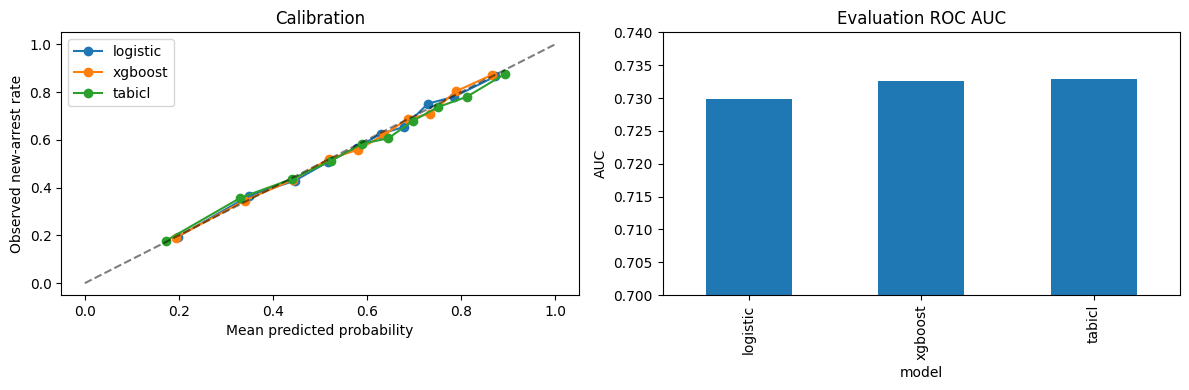

In [12]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name,p in probabilities.items():
    bins=pd.qcut(p,10,duplicates='drop')
    curve=pd.DataFrame({'p':p,'y':y_eval,'bin':bins}).groupby('bin',observed=True)[['p','y']].mean()
    axes[0].plot(curve.p,curve.y,marker='o',label=name)
axes[0].plot([0,1],[0,1],'k--',alpha=.5)
axes[0].set(xlabel='Mean predicted probability',ylabel='Observed new-arrest rate',title='Calibration')
axes[0].legend()
metrics.roc_auc.plot.bar(ax=axes[1],ylim=(.70,.74),title='Evaluation ROC AUC')
axes[1].set_ylabel('AUC')
plt.tight_layout(); plt.show()

### Paired uncertainty and a hypothetical economic scenario

The same bootstrap row sample is applied to both models, preserving the pairing. These intervals describe sampling variation conditional on the already selected models; they do not correct the repeated inspection of evaluation labels. Economic values assume 20% intervention effectiveness, a €50,000 event cost and €5,000 support cost. These are scenarios, not estimated causal savings.

In [13]:
rng=np.random.default_rng(SEED)
pair_draws=[]
for _ in range(500):
    ix=rng.integers(0,len(y_eval),len(y_eval))
    yy=y_eval.to_numpy()[ix]
    if len(np.unique(yy))<2: continue
    a=probabilities['xgboost'][ix]; b=probabilities['logistic'][ix]
    pair_draws.append((roc_auc_score(yy,a)-roc_auc_score(yy,b),
                       brier_score_loss(yy,a)-brier_score_loss(yy,b)))
pair_draws=np.asarray(pair_draws)
display(pd.DataFrame({'comparison':['XGBoost - logistic AUC','XGBoost - logistic Brier'],
                      'point':[metrics.loc['xgboost','roc_auc']-metrics.loc['logistic','roc_auc'],
                               metrics.loc['xgboost','brier']-metrics.loc['logistic','brier']],
                      'low':np.quantile(pair_draws,.025,axis=0),
                      'high':np.quantile(pair_draws,.975,axis=0)}))
economics=[]
for name,p in probabilities.items():
    chosen=select_top(p)
    captured=int(y_eval[chosen].sum())
    economics.append({'model':name,'offers':int(chosen.sum()),'observed_events_in_offers':captured,
                      'assumed_gross_eur':captured*50000*.20,
                      'assumed_cost_eur':chosen.sum()*5000,
                      'assumed_net_eur':captured*50000*.20-chosen.sum()*5000})
display(pd.DataFrame(economics).set_index('model'))

,comparison,point,low,high
0,XGBoost - logistic AUC,0.002768,0.000767,0.004672
1,XGBoost - logistic Brier,-0.001006,-0.001600,-0.000338


,offers,observed_events_in_offers,assumed_gross_eur,assumed_cost_eur,assumed_net_eur
model,,,,,
logistic,1561,1285,12850000.0,7805000,5045000.0
xgboost,1561,1307,13070000.0,7805000,5265000.0
tabicl,1561,1293,12930000.0,7805000,5125000.0


## 7. Interpret what the models use

We ask the course's three questions: what drives each model overall (**global**), why one person receives their score (**local**), and which fields earn the model its accuracy (**performance**). Each model is read with the tool that suits it: logistic regression through its own coefficients, XGBoost through exact TreeSHAP, and TabICLv2, which has neither coefficients nor a fast exact explainer, from outside with PDP, ICE and LIME. All of these describe model behaviour, not causal effects.

### Global: logistic regression, read from its coefficients

Every category is one-hot encoded, so a single coefficient has no reference level. We therefore report odds ratios between two levels, exp(β_a − β_b). Age bands are compared with 48 or older, and prior felony arrests with one arrest: only about 2% of training rows have none, so that level's coefficient is unstable. The Georgia risk score is standardised inside the pipeline, so its coefficient is divided by the training standard deviation to give a per-point effect.

,field,contrast,odds_ratio
0,Age,18-22 vs 48 or older,5.77
1,Age,23-27 vs 48 or older,3.76
2,Age,28-32 vs 48 or older,2.52
3,Age,33-37 vs 48 or older,1.84
4,Age,38-42 vs 48 or older,1.60
5,Age,43-47 vs 48 or older,1.32
6,Prior felony arrests,0 vs 1,2.38
7,Prior felony arrests,2 vs 1,1.26
8,Prior felony arrests,3 vs 1,1.43
9,Prior felony arrests,4 vs 1,1.58


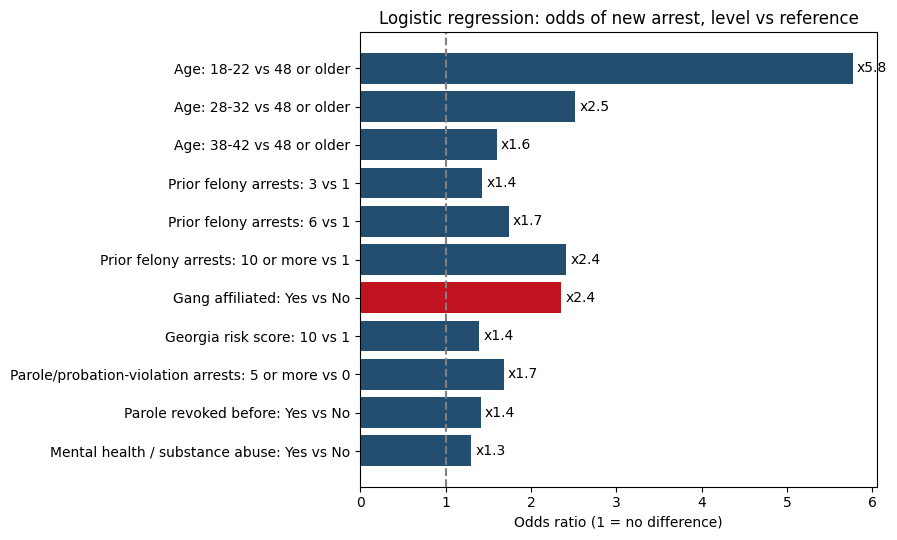

In [14]:
logit=models['logistic']
coef=pd.Series(logit[-1].coef_[0],index=logit[-2].get_feature_names_out())
numeric_cols=list(logit[-2].transformers_[0][2])
score_sd=logit[-2].named_transformers_['numeric']['scale'].scale_[numeric_cols.index('Supervision_Risk_Score_First')]

def odds(field,level,reference):
    return float(np.exp(coef[f'{field}_{level}']-coef[f'{field}_{reference}']))

felony_levels=['0','2','3','4','5','6','7','8','9','10 or more']
odds_ratios=pd.DataFrame(
    [('Age',f'{band} vs 48 or older',odds('Age_at_Release',band,'48 or older')) for band in age_order[:-1]]
    +[('Prior felony arrests',f'{n} vs 1',odds('Prior_Arrest_Episodes_Felony',n,'1')) for n in felony_levels]
    +[('Other','Gang affiliated: Yes vs No',odds('Gang_Affiliated','Yes','No')),
      ('Other','Georgia risk score: 10 vs 1',float(np.exp(9*coef['Supervision_Risk_Score_First']/score_sd))),
      ('Other','Parole/probation-violation arrests: 5 or more vs 0',odds('_v1','5 or more','0')),
      ('Other','Parole revoked before: Yes vs No',odds('Prior_Revocations_Parole','Yes','No')),
      ('Other','Mental health / substance abuse: Yes vs No',odds('Condition_MH_SA','Yes','No'))],
    columns=['field','contrast','odds_ratio'])
display(odds_ratios.round(2))

shown=odds_ratios[odds_ratios.field.eq('Other')|odds_ratios.contrast.isin(
    ['18-22 vs 48 or older','28-32 vs 48 or older','38-42 vs 48 or older','3 vs 1','6 vs 1','10 or more vs 1'])][::-1]
labels=[c if f=='Other' else f'{f}: {c}' for f,c in zip(shown.field,shown.contrast)]
fig,ax=plt.subplots(figsize=(9,5.5))
ax.barh(labels,shown.odds_ratio,color=['#c1121f' if 'Gang' in l else '#234e70' for l in labels])
ax.axvline(1,color='grey',ls='--')
for y,v in enumerate(shown.odds_ratio):
    ax.text(v+.05,y,f'x{v:.1f}',va='center')
ax.set(xlabel='Odds ratio (1 = no difference)',title='Logistic regression: odds of new arrest, level vs reference')
plt.tight_layout(); plt.show()

The same contrasts on the probability scale are **average marginal effects**: set every evaluation row to one level, then to the reference, and average the change in predicted probability. For a categorical field this is exactly a difference between two points of a partial dependence curve.

In [15]:
base_p=logit.predict_proba(X_eval)[:,1]
effects=[]
for feature in FEATURES:
    observed=X_train[feature].dropna()
    if pd.api.types.is_numeric_dtype(X_train[feature]):
        scale=observed.std()
        changed=X_eval.copy()
        changed[feature]=changed[feature].fillna(observed.median())+scale
        effect=(logit.predict_proba(changed)[:,1]-base_p).mean()
        effects.append({'feature':feature,'contrast':'+1 training SD','mean_probability_change':effect})
    else:
        reference=observed.mode().iloc[0]
        ref=X_eval.copy(); ref[feature]=reference
        ref_p=logit.predict_proba(ref)[:,1]
        for level in observed.unique():
            if level==reference: continue
            changed=X_eval.copy(); changed[feature]=level
            effect=(logit.predict_proba(changed)[:,1]-ref_p).mean()
            effects.append({'feature':feature,'contrast':f'{level} vs {reference}',
                            'mean_probability_change':effect})
effects=pd.DataFrame(effects)
display(effects.reindex(effects.mean_probability_change.abs().sort_values(ascending=False).index).head(15))

,feature,contrast,mean_probability_change
2,Age_at_Release,48 or older vs 23-27,-0.274041
0,Age_at_Release,43-47 vs 23-27,-0.215013
30,Prior_Arrest_Episodes_Felony,1 vs 10 or more,-0.185165
3,Age_at_Release,38-42 vs 23-27,-0.174233
6,Gang_Affiliated,Yes vs No,0.167875
1,Age_at_Release,33-37 vs 23-27,-0.143834
29,Prior_Arrest_Episodes_Felony,2 vs 10 or more,-0.135103
52,_v1,5 or more vs 0,0.108672
26,Prior_Arrest_Episodes_Felony,3 vs 10 or more,-0.108151
23,Prior_Arrest_Episodes_Felony,7 vs 10 or more,-0.098930


### Global: XGBoost, through SHAP

TreeSHAP computes exact SHAP values for tree ensembles in seconds, so every evaluation person is explained. In the summary plot each dot is a person: further right raises predicted risk, and the colour is the field's value (ordered categories by rank). A depth-three decision tree then tries to mimic XGBoost; its R² on evaluation probabilities shows how much of the model a readable surrogate can actually explain.

,mean_abs_shap
Age_at_Release,0.388786
Gang_Affiliated,0.197800
Prior_Arrest_Episodes_Felony,0.164388
_v1,0.157486
Prison_Years,0.147202
Prior_Arrest_Episodes_Property,0.132720
Prior_Arrest_Episodes_Misd,0.117559
Condition_MH_SA,0.109491
Supervision_Risk_Score_First,0.099734
Prior_Conviction_Episodes_Misd,0.085827


C:\Users\andre\AppData\Local\Temp\ipykernel_16124\2800768810.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_raw.to_numpy(),colour.to_numpy(float),feature_names=FEATURES,max_display=8,show=False)


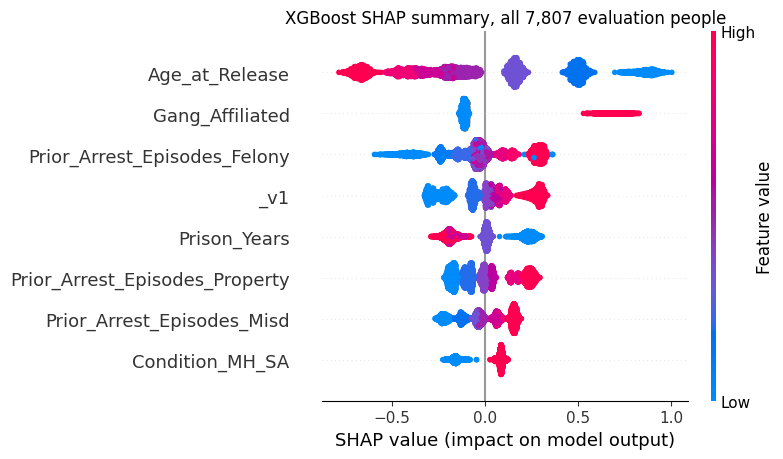

Depth-three surrogate R² on evaluation probabilities: 0.608


In [16]:
import shap

pipe=models['xgboost']
prepared=pipe[:-1].transform(X_eval)
prepared=prepared.toarray() if hasattr(prepared,'toarray') else prepared
shap_values=shap.TreeExplainer(pipe[-1]).shap_values(prepared)
transformed_names=pipe[-2].get_feature_names_out()
def original_field(name):
    name=str(name).removeprefix('missingindicator_')
    match=[f for f in FEATURES if name==f or name.startswith(f+'_')]
    return max(match,key=len) if match else name
fields=[original_field(n) for n in transformed_names]
shap_raw=pd.DataFrame(shap_values,columns=transformed_names).T.groupby(fields).sum().T[FEATURES]
shap_global=shap_raw.abs().mean().sort_values(ascending=False)
display(shap_global.head(10).rename('mean_abs_shap').to_frame())
colour=ordinal_encode(X_eval).apply(lambda c: c if pd.api.types.is_numeric_dtype(c)
                                    else c.astype('category').cat.codes.replace(-1,np.nan))
shap.summary_plot(shap_raw.to_numpy(),colour.to_numpy(float),feature_names=FEATURES,max_display=8,show=False)
plt.title(f'XGBoost SHAP summary, all {len(X_eval):,} evaluation people'); plt.tight_layout(); plt.show()

encoded_train=pd.get_dummies(ordinal_encode(X_train)).fillna(-1)
encoded_eval=pd.get_dummies(ordinal_encode(X_eval)).reindex(columns=encoded_train.columns,fill_value=0).fillna(-1)
surrogate=DecisionTreeRegressor(max_depth=3,min_samples_leaf=200,random_state=SEED)
surrogate.fit(encoded_train,models['xgboost'].predict_proba(X_train)[:,1])
surrogate_r2=r2_score(probabilities['xgboost'],surrogate.predict(encoded_eval))
print('Depth-three surrogate R² on evaluation probabilities:',round(surrogate_r2,3))

### Global, from outside: PDP and ICE for all three models

The same 200 evaluation people are set to every age band, to gang affiliation No and Yes, and to every prior-felony count. Each person's predictions form one ICE curve; their average is the partial dependence (PDP). This is model-agnostic, so it is the global view available for TabICLv2 too. The PDP difference between two levels is the average marginal effect in percentage points.

,logistic,xgboost,tabicl
PDP difference (points),,,
Age 23-27 -> 48 or older,-27.5,-26.1,-29.299999
Gang No -> Yes,16.7,15.6,17.299999
Felony arrests 1 -> 10 or more,18.1,14.9,17.100000


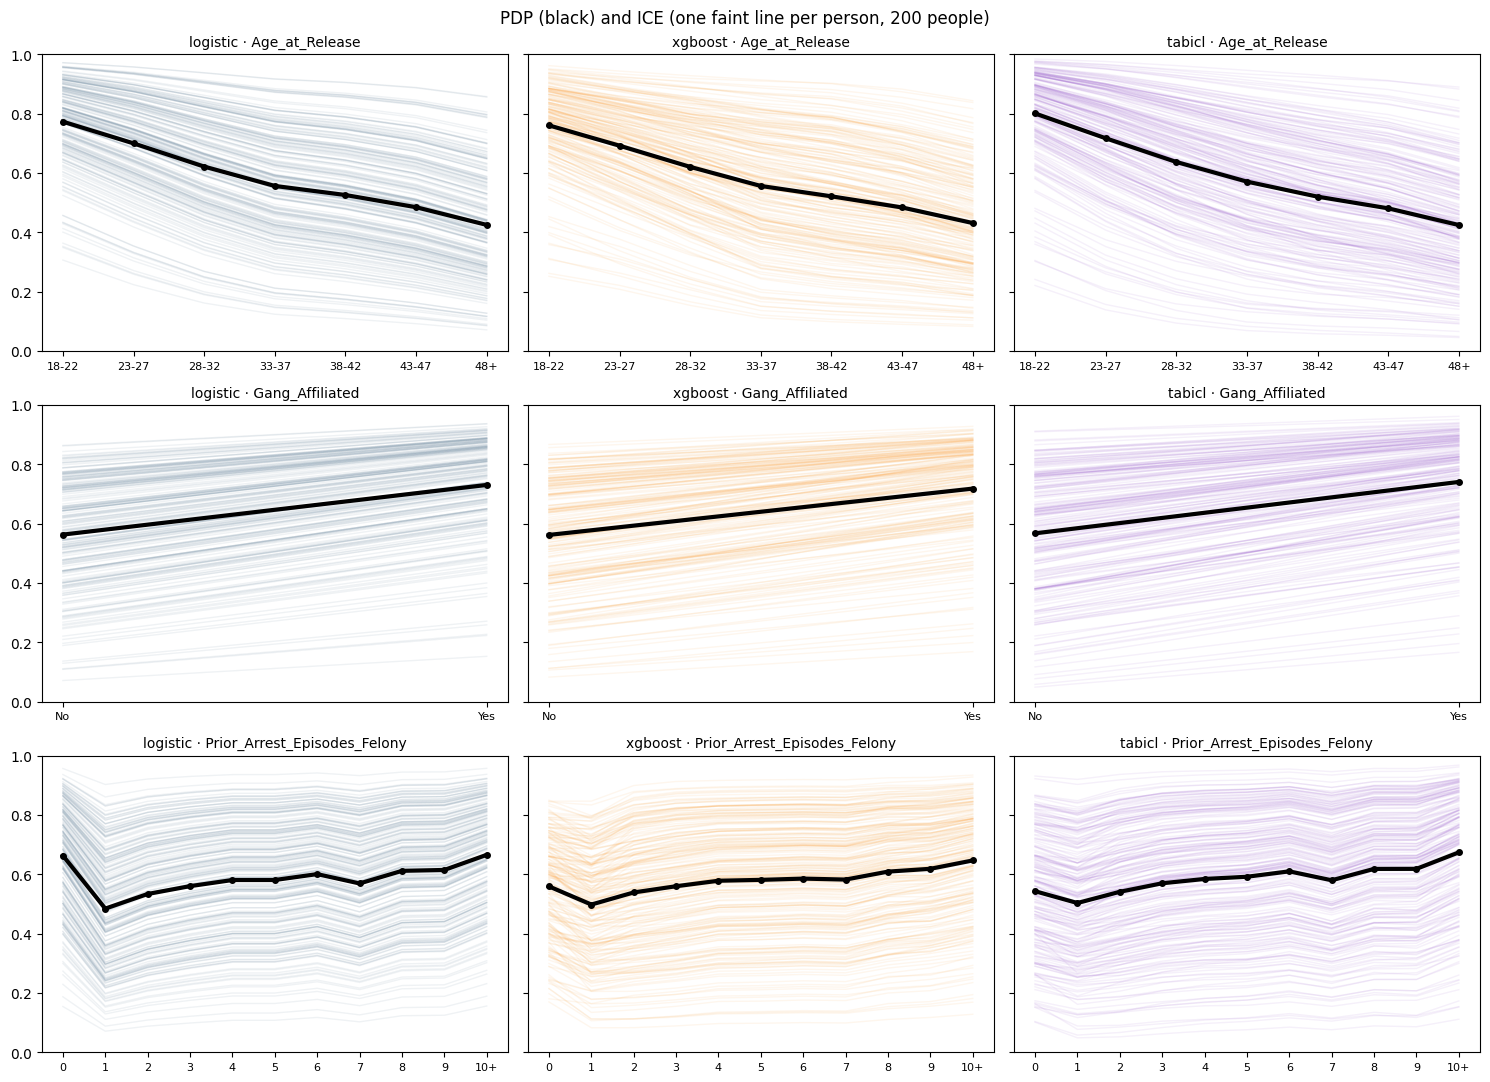

In [17]:
def predict(name,frame):
    frame=frame.fillna(category_modes) if name=='tabicl' else frame
    return models[name].predict_proba(frame)[:,1]

ice_ix=np.random.default_rng(SEED).choice(len(X_eval),1000,replace=False)[:200]
ice_people=X_eval.iloc[ice_ix].reset_index(drop=True)
grid={'Age_at_Release':age_order,'Gang_Affiliated':['No','Yes'],
      'Prior_Arrest_Episodes_Felony':['0','1','2','3','4','5','6','7','8','9','10 or more']}
settings=[(f,v) for f,values in grid.items() for v in values]
batch=pd.concat([ice_people.assign(**{f:v}) for f,v in settings],ignore_index=True)
ice={name:pd.DataFrame(predict(name,batch).reshape(len(settings),len(ice_people)).T,
                       columns=pd.MultiIndex.from_tuples(settings)) for name in models}
contrasts=pd.DataFrame({name:{
    'Age 23-27 -> 48 or older':f[('Age_at_Release','48 or older')].mean()-f[('Age_at_Release','23-27')].mean(),
    'Gang No -> Yes':f[('Gang_Affiliated','Yes')].mean()-f[('Gang_Affiliated','No')].mean(),
    'Felony arrests 1 -> 10 or more':f[('Prior_Arrest_Episodes_Felony','10 or more')].mean()
                                    -f[('Prior_Arrest_Episodes_Felony','1')].mean()} for name,f in ice.items()})
display((100*contrasts).round(1).rename_axis('PDP difference (points)'))

colours={'logistic':'#234e70','xgboost':'#fb8500','tabicl':'#7b2cbf'}
fig,axes=plt.subplots(3,3,figsize=(15,11),sharey=True)
for c,(name,frame) in enumerate(ice.items()):
    for r,(feature,values) in enumerate(grid.items()):
        ax=axes[r][c]; x=np.arange(len(values)); curves=frame[feature][values]
        for _,curve in curves.iterrows():
            ax.plot(x,curve.to_numpy(),color=colours[name],alpha=.07,lw=1)
        ax.plot(x,curves.mean().to_numpy(),color='black',lw=3,marker='o',ms=4)
        ax.set_xticks(x,[v.replace(' or more','+').replace(' or older','+') for v in values],fontsize=8)
        ax.set_title(f'{name} · {feature}',fontsize=10); ax.set_ylim(0,1)
fig.suptitle('PDP (black) and ICE (one faint line per person, 200 people)'); plt.tight_layout(); plt.show()

### Local: one person on the support cut-off

A local explanation matters most where a small change decides the offer. Among the same 200 people we take the one whose predicted risk is closest to the top-20% cut-off in all three models, fixed by that rule before looking at any explanation. Logistic regression is explained by coefficient × (value − training average) on each prepared column, summed back to raw fields: for a linear model this is exactly its SHAP value. XGBoost uses TreeSHAP. For TabICLv2 we read this person's own ICE curves against the cut-off.

,raw value
Age_at_Release,28-32
Gang_Affiliated,Yes
Supervision_Risk_Score_First,8.0
Supervision_Level_First,High
Education_Level,High School Diploma
Dependents,0
Prison_Offense,Violent/Non-Sex
Prison_Years,More than 3 years
Prior_Arrest_Episodes_Felony,3
Prior_Arrest_Episodes_Misd,3


,risk,cutoff,offered_support,risk_if_gang_No
logistic,0.755,0.756,False,0.566
xgboost,0.764,0.760,True,0.574
tabicl,0.785,0.781,True,0.591


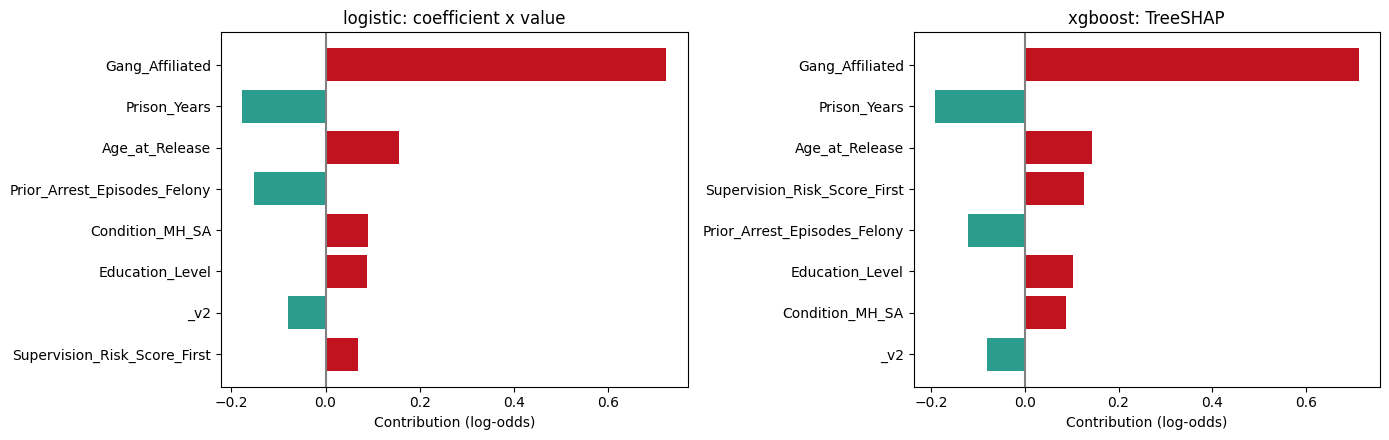

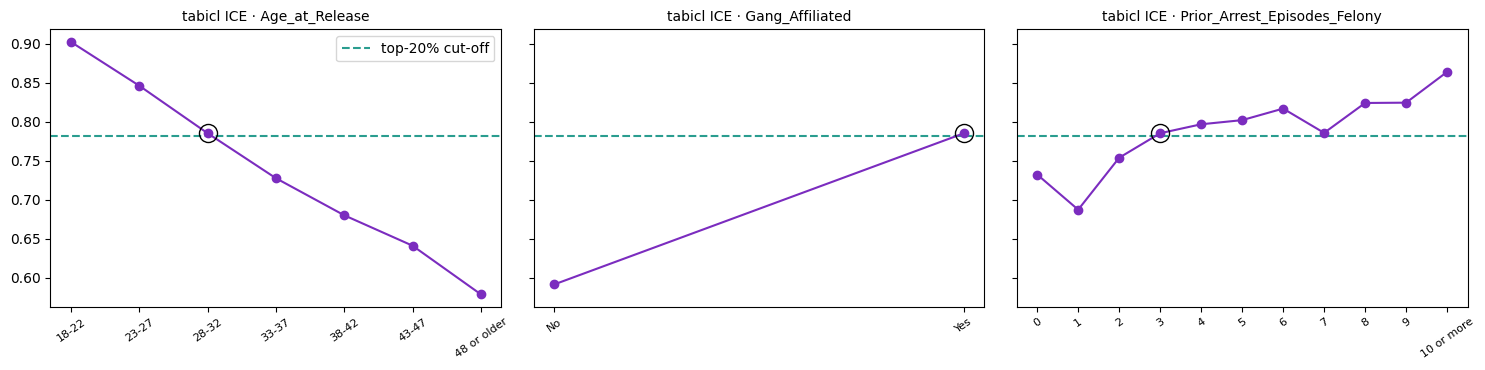

In [18]:
cutoff={name:float(np.sort(p)[::-1][round(len(p)*.20)-1]) for name,p in probabilities.items()}
own=pd.DataFrame({name:probabilities[name][ice_ix] for name in models})
person_ix=int((own-pd.Series(cutoff)).abs().sum(axis=1).idxmin())
person=ice_people.iloc[[person_ix]]
display(person.T.rename(columns={person_ix:'raw value'}).head(10))

def dense(matrix):
    return matrix.toarray() if hasattr(matrix,'toarray') else matrix
background=dense(logit[:-1].transform(X_train)).mean(axis=0)
logit_fields=[original_field(n) for n in logit[-2].get_feature_names_out()]
contrib_logit=pd.Series((dense(logit[:-1].transform(person))[0]-background)*logit[-1].coef_[0],
                        index=logit_fields).groupby(level=0).sum()
contrib_xgb=pd.Series(shap.TreeExplainer(pipe[-1]).shap_values(dense(pipe[:-1].transform(person)))[0],
                      index=fields).groupby(level=0).sum()

local=pd.DataFrame({'risk':own.iloc[person_ix],'cutoff':pd.Series(cutoff)})
local['offered_support']=local.risk>=local.cutoff
local['risk_if_gang_No']=[ice[name][('Gang_Affiliated','No')].iloc[person_ix] for name in local.index]
display(local.round(3))

fig,axes=plt.subplots(1,2,figsize=(14,4.5))
for ax,(name,contrib) in zip(axes,[('logistic: coefficient x value',contrib_logit),('xgboost: TreeSHAP',contrib_xgb)]):
    top=contrib.reindex(contrib.abs().sort_values(ascending=False).index[:8])[::-1]
    ax.barh(top.index,top.values,color=['#c1121f' if v>0 else '#2a9d8f' for v in top.values])
    ax.axvline(0,color='grey'); ax.set(title=name,xlabel='Contribution (log-odds)')
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,3.8),sharey=True)
for ax,(feature,values) in zip(axes,grid.items()):
    curve=ice['tabicl'][feature][values].iloc[person_ix]
    ax.axhline(cutoff['tabicl'],color='#2a9d8f',ls='--',label='top-20% cut-off')
    ax.plot(values,curve.to_numpy(),color=colours['tabicl'],marker='o')
    ax.plot(person[feature].iloc[0],curve[person[feature].iloc[0]],'o',ms=13,mfc='none',mec='black')
    ax.set_title(f'tabicl ICE · {feature}',fontsize=10); ax.tick_params(axis='x',labelsize=8,rotation=35)
axes[0].legend(); plt.tight_layout(); plt.show()

### Local explanation with a fidelity check

LIME samples nearby raw-feature values. Categorical variables are declared as categories so it does not create impossible combinations of independent one-hot flags. Its weighted local R² measures how faithfully the small surrogate approximates XGBoost around the chosen person. A low R² means the explanation should be treated cautiously.

,case,seed,local_r2,model_probability
0,low,0,0.483776,0.077922
1,low,1,0.483066,0.077922
2,low,2,0.485463,0.077922
3,median,0,0.265180,0.609130
4,median,1,0.284697,0.609130
5,median,2,0.270641,0.609130
6,high,0,0.406346,0.944824
7,high,1,0.409146,0.944824
8,high,2,0.392858,0.944824


3    [(Gang_Affiliated=No, -0.16526138768550125), (...
Name: top_rules, dtype: object

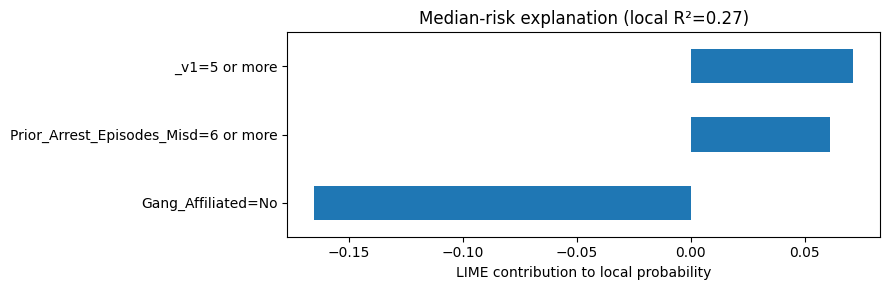

In [19]:
from lime.lime_tabular import LimeTabularExplainer

def lime_space(training, evaluation):
    nums=training.select_dtypes(include='number').columns.tolist()
    cats=[c for c in training if c not in nums]
    med=training[nums].median()
    modes={c:training[c].mode().iloc[0] for c in cats}
    levels={c:sorted(map(str,training[c].fillna(modes[c]).unique())) for c in cats}
    def encode(frame):
        out=pd.DataFrame(index=frame.index)
        for c in training:
            if c in nums: out[c]=frame[c].fillna(med[c]).astype(float)
            else:
                lookup={v:i for i,v in enumerate(levels[c])}
                out[c]=frame[c].fillna(modes[c]).astype(str).map(lookup).astype(float)
        return out[training.columns].to_numpy(float)
    def decode(array):
        out=pd.DataFrame(array,columns=training.columns)
        for c in cats:
            ix=np.clip(np.rint(out[c]).astype(int),0,len(levels[c])-1)
            out[c]=[levels[c][i] for i in ix]
        return out
    cat_ix=[list(training.columns).index(c) for c in cats]
    names={i:levels[training.columns[i]] for i in cat_ix}
    return encode(training),encode(evaluation),decode,cat_ix,names

lime_train,lime_eval,decode,cat_ix,cat_names=lime_space(X_train,X_eval)
xgb_p=probabilities['xgboost']
case_indices={'low':int(np.argmin(xgb_p)),'median':int(np.argsort(xgb_p)[len(xgb_p)//2]),
              'high':int(np.argmax(xgb_p))}
lime_rows=[]
for case,ix in case_indices.items():
    for seed in (0,1,2):
        explainer=LimeTabularExplainer(lime_train,feature_names=FEATURES,
            categorical_features=cat_ix,categorical_names=cat_names,
            class_names=['no','yes'],discretize_continuous=True,random_state=seed)
        explanation=explainer.explain_instance(lime_eval[ix],
            lambda z:models['xgboost'].predict_proba(decode(z)),num_features=10,num_samples=3000)
        lime_rows.append({'case':case,'seed':seed,'local_r2':explanation.score,
                          'model_probability':xgb_p[ix],
                          'top_rules':explanation.as_list()[:3]})
lime_results=pd.DataFrame(lime_rows)
display(lime_results[['case','seed','local_r2','model_probability']])
display(lime_results.loc[(lime_results.case=='median')&(lime_results.seed==0),'top_rules'])
median_rules=lime_results.loc[(lime_results.case=='median')&(lime_results.seed==0),'top_rules'].iloc[0]
fig,ax=plt.subplots(figsize=(9,3))
pd.Series(dict(median_rules)).sort_values().plot.barh(ax=ax)
ax.set(xlabel='LIME contribution to local probability',
       title=f'Median-risk explanation (local R²={lime_results.loc[(lime_results.case=="median") & (lime_results.seed==0),"local_r2"].iloc[0]:.2f})')
plt.tight_layout(); plt.show()

LIME is then run on the same person for all three models (three seeds each; 1,000 perturbed rows for TabICLv2 instead of 5,000, because each of its predictions is expensive). We check whether its top reason matches the explanations above and whether each condition has the same sign as SHAP.

In [20]:
_,person_arr,_,_,_=lime_space(X_train,person)
lime_person=[]
for name in models:
    def proba(z,name=name):
        q=predict(name,decode(z)); return np.column_stack([1-q,q])
    for seed in (0,1,2):
        explainer=LimeTabularExplainer(lime_train,feature_names=FEATURES,categorical_features=cat_ix,
                                       categorical_names=cat_names,class_names=['no','yes'],
                                       discretize_continuous=True,random_state=seed)
        explanation=explainer.explain_instance(person_arr[0],proba,num_features=10,
                                               num_samples=1000 if name=='tabicl' else 5000)
        for condition,weight in explanation.as_list():
            field=max((f for f in FEATURES if condition.startswith(f) or f' {f} ' in f' {condition} '),key=len)
            shap_value={'logistic':contrib_logit,'xgboost':contrib_xgb}.get(name,pd.Series(dtype=float)).get(field,np.nan)
            lime_person.append({'model':name,'seed':seed,'condition':condition,'weight':weight,
                                'shap':shap_value,'local_r2':explanation.score})
lime_person=pd.DataFrame(lime_person)
top=lime_person.loc[lime_person.groupby(['model','seed']).weight.apply(lambda w:w.abs().idxmax())]
checked=lime_person.dropna(subset=['shap'])
display(pd.DataFrame({'top_reason':top.groupby('model').condition.agg(lambda c:', '.join(sorted(set(c)))),
                      'local_r2':lime_person.groupby('model').local_r2.mean()}).round(3))
print('Conditions with the same sign as SHAP (logistic, XGBoost):',
      int((checked.weight.gt(0)==checked.shap.gt(0)).sum()),'of',len(checked))

,top_reason,local_r2
model,,
logistic,Gang_Affiliated=Yes,0.231
tabicl,Gang_Affiliated=Yes,0.255
xgboost,Gang_Affiliated=Yes,0.231


Conditions with the same sign as SHAP (logistic, XGBoost): 60 of 60


### One person's complete path

The median-risk evaluation person is fixed by XGBoost's rank. We show their raw fields, trained preprocessing, three probabilities, local explanation and support decision. These are predictions, not a diagnosis or a reason to impose a sanction.

In [21]:
ix=case_indices['median']
person=X_eval.iloc[[ix]]
print('Anonymized record ID:',int(audit_eval.ID.iloc[ix]))
display(person.T.rename(columns={ix:'raw value'}))
prepared=models['logistic'][:-1].transform(person)
print('Logistic prepared matrix:',prepared.shape,
      '; nonzero values:',int(prepared.nnz if hasattr(prepared,'nnz') else np.count_nonzero(prepared)))
display(pd.DataFrame({'model':list(probabilities),
                      'risk':[float(probabilities[m][ix]) for m in probabilities]}))
rank=int((xgb_p>xgb_p[ix]).sum())+1
print(f'XGBoost rank {rank} of {len(xgb_p)}; support offer at 20% capacity:',
      bool(select_top(xgb_p)[ix]))
print('LIME local R² for this case:',
      lime_results.loc[lime_results.case=='median','local_r2'].round(3).tolist())

Anonymized record ID: 23257


,raw value
Age_at_Release,33-37
Gang_Affiliated,No
Supervision_Risk_Score_First,4.0
Supervision_Level_First,Standard
Education_Level,Less than HS diploma
Dependents,0
Prison_Offense,NaN
Prison_Years,1-2 years
Prior_Arrest_Episodes_Felony,5
Prior_Arrest_Episodes_Misd,6 or more


Logistic prepared matrix: (1, 108) ; nonzero values: 30


,model,risk
0,logistic,0.626400
1,xgboost,0.609130
2,tabicl,0.619446


XGBoost rank 3904 of 7807; support offer at 20% capacity: False
LIME local R² for this case: [0.265, 0.285, 0.271]


### Performance: which fields earn the accuracy

SHAP and LIME explain predictions. **XPER** (Hué, Hurlin, Pérignon and Saurin) explains performance: it splits the AUC itself into a benchmark, the AUC of an uninformative model, plus one contribution per field. It needs many coalition evaluations, so it runs on 150 evaluation people with a kernel approximation, and is not run for TabICLv2. **Permutation importance** shuffles one field and measures how much the Brier score worsens, on 1,000 evaluation people. TabICLv2 is measured on 14 fields only, since each shuffle needs a full foundation-model prediction pass.

In [22]:
perf_ix=np.random.default_rng(SEED).choice(len(X_eval),1000,replace=False)
X_perf,y_perf=X_eval.iloc[perf_ix].reset_index(drop=True),y_eval.iloc[perf_ix].reset_index(drop=True)
importance=[]
for name in ['logistic','xgboost']:
    result=permutation_importance(models[name],X_perf,y_perf,scoring='neg_brier_score',
                                  n_repeats=5,random_state=SEED,n_jobs=1)
    importance+=[{'model':name,'feature':f,'brier_increase':v} for f,v in zip(FEATURES,result.importances_mean)]
tabicl_fields=['Supervision_Risk_Score_First','Age_at_Release','Gang_Affiliated','Prior_Arrest_Episodes_Felony',
               'Prior_Arrest_Episodes_Misd','Prior_Arrest_Episodes_Violent','Prior_Arrest_Episodes_Drug',
               'Education_Level','Prison_Years','Supervision_Level_First','_v1','Prior_Conviction_Episodes_Misd',
               'Condition_MH_SA','Prior_Arrest_Episodes_Property']
base_brier=brier_score_loss(y_perf,predict('tabicl',X_perf))
rng=np.random.default_rng(SEED)
for f in tabicl_fields:
    shuffled=X_perf.copy(); shuffled[f]=rng.permutation(shuffled[f].to_numpy())
    importance.append({'model':'tabicl','feature':f,
                       'brier_increase':brier_score_loss(y_perf,predict('tabicl',shuffled))-base_brier})
importance=pd.DataFrame(importance).pivot(index='feature',columns='model',values='brier_increase')
display(importance.sort_values('logistic',ascending=False).head(10).round(4))
print('Permutation importance is descriptive on this repeatedly inspected evaluation cohort.')

model,logistic,tabicl,xgboost
feature,,,
Age_at_Release,0.0165,0.0168,0.0140
Prior_Arrest_Episodes_Felony,0.0083,0.0090,0.0061
Gang_Affiliated,0.0070,0.0084,0.0063
_v1,0.0044,0.0017,0.0045
Prison_Years,0.0043,0.0022,0.0041
Prior_Arrest_Episodes_Property,0.0036,0.0048,0.0040
Prior_Arrest_Episodes_Misd,0.0032,0.0037,0.0030
Condition_MH_SA,0.0019,0.0006,0.0015
Prior_Conviction_Episodes_Misd,0.0016,0.0022,0.0011


Permutation importance is descriptive on this repeatedly inspected evaluation cohort.


In [23]:
from XPER.compute.Performance import ModelPerformance

def xper_for(name):
    xp=ModelPerformance(X_train,y_train,X_eval,y_eval,models[name],sample_size=150,seed=SEED)
    phi,_=xp.calculate_XPER_values(['AUC'],N_coalition_sampled=60,kernel=True,seed=SEED)
    print(f'{name}: benchmark AUC {phi[0]:.3f}, sample AUC {float(xp.evaluate(["AUC"])):.3f}, '
          f'sum of contributions {phi.sum():.3f}')
    return pd.Series(phi[1:],index=FEATURES,name=name)

xper=pd.concat([xper_for('logistic')],axis=1)

C:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\XPER\compute\Performance.py:77: UserWarning: The input data was provided as a pandas DataFrame. For internal computations, the data will be converted to NumPy arrays to improve speed. However, because the model may have been trained with DataFrame feature names, predictions may require converting arrays back to DataFrames, which can slow down repeated prediction calls. If your model can make predictions directly from NumPy arrays without raising feature-name or dtype errors, provide X_train and X_test directly as NumPy arrays for faster computation.
  self.model = self._model(model, X_train, self.metadata_train)


Coalitions:   0%|          | 0/60 [00:00<?, ?coalition/s]

Coalitions:   2%|▏         | 1/60 [11:19<11:08:05, 679.42s/coalition]

Coalitions:   3%|▎         | 2/60 [11:19<4:30:35, 279.92s/coalition] 

Coalitions:   5%|▌         | 3/60 [11:20<2:24:57, 152.58s/coalition]

...

Coalitions:  93%|█████████▎| 56/60 [11:46<00:00,  7.59coalition/s]

Coalitions:  97%|█████████▋| 58/60 [11:46<00:00,  6.53coalition/s]

Coalitions: 100%|██████████| 60/60 [11:46<00:00,  8.29coalition/s]

Coalitions: 100%|██████████| 60/60 [11:46<00:00, 11.78s/coalition]

logistic: benchmark AUC 0.476, sample AUC 0.722, sum of contributions 0.740


C:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\XPER\compute\Performance.py:77: UserWarning: The input data was provided as a pandas DataFrame. For internal computations, the data will be converted to NumPy arrays to improve speed. However, because the model may have been trained with DataFrame feature names, predictions may require converting arrays back to DataFrames, which can slow down repeated prediction calls. If your model can make predictions directly from NumPy arrays without raising feature-name or dtype errors, provide X_train and X_test directly as NumPy arrays for faster computation.
  self.model = self._model(model, X_train, self.metadata_train)


Coalitions:   0%|          | 0/60 [00:00<?, ?coalition/s]

Coalitions:   2%|▏         | 1/60 [20:25<20:05:01, 1225.44s/coalition]

Coalitions:   3%|▎         | 2/60 [20:38<8:15:12, 512.28s/coalition]  

Coalitions:   5%|▌         | 3/60 [20:40<4:25:24, 279.37s/coalition]

...

Coalitions:  95%|█████████▌| 57/60 [21:39<00:00,  3.54coalition/s]

Coalitions: 100%|██████████| 60/60 [21:39<00:00,  6.81coalition/s]

Coalitions: 100%|██████████| 60/60 [21:39<00:00, 21.66s/coalition]

xgboost: benchmark AUC 0.470, sample AUC 0.729, sum of contributions 0.751


,logistic,xgboost
Age_at_Release,0.089,0.084
Prior_Arrest_Episodes_Felony,0.043,0.047
_v1,0.029,0.032
Prior_Arrest_Episodes_Misd,0.028,0.032
Gang_Affiliated,0.025,0.027
Prior_Conviction_Episodes_Misd,0.020,0.020
Condition_MH_SA,0.016,0.015
Prison_Years,0.008,0.010


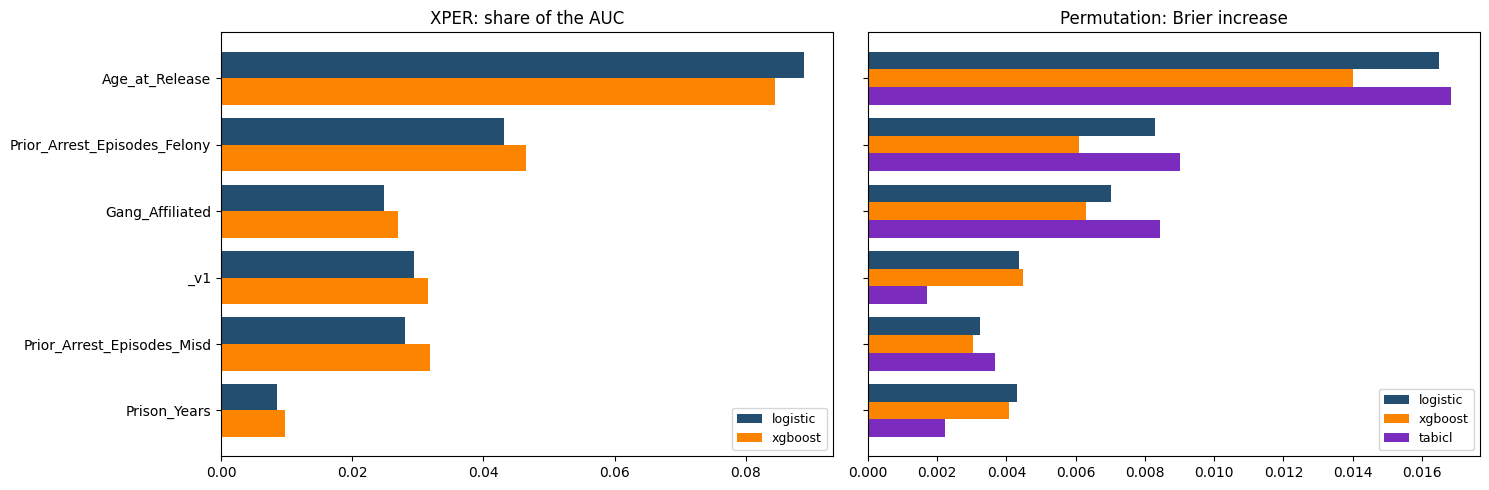

In [24]:
xper['xgboost']=xper_for('xgboost')
display(xper.sort_values('logistic',ascending=False).head(8).round(3))

rank=(xper.rank(ascending=False).mean(axis=1)+importance[['logistic','xgboost']].rank(ascending=False).mean(axis=1))/2
shown_fields=rank.sort_values().index[:5].tolist()
shown_fields+=[f for f in ['Prison_Years'] if f not in shown_fields]
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True)
for ax,frame,names,title in [(axes[0],xper,['logistic','xgboost'],'XPER: share of the AUC'),
                             (axes[1],importance,['logistic','xgboost','tabicl'],'Permutation: Brier increase')]:
    y=np.arange(len(shown_fields))[::-1]; h=.8/len(names)
    for j,name in enumerate(names):
        ax.barh(y+(len(names)-1)/2*h-j*h,frame.reindex(shown_fields)[name].fillna(0),h,color=colours[name],label=name)
    ax.set(title=title); ax.legend(fontsize=9)
axes[0].set_yticks(np.arange(len(shown_fields))[::-1],shown_fields)
plt.tight_layout(); plt.show()

All three explanation routes put the same fields on top: age, prior record and gang affiliation. Their exact order differs between methods, because they answer different questions (a prediction, a loss, a ranking metric), so we quote the set of drivers rather than a ranking. Explaining also becomes harder with complexity: logistic regression explains itself, XGBoost needs SHAP, and TabICLv2 can only be probed from outside. On the person at the cut-off, all three models' explanations point to gang affiliation, a field that is never recorded for women (section 4); section 9 audits what this does to fairness.

## 8. Stability under training resampling

Each model is refitted on the same bootstrap samples of the *training* partition. We compare its new evaluation scores and selected set to its original fit. This measures training-data sensitivity, not future population shift. TabICL refits are compute-heavy and therefore measured with three shared resamples here; the repository's expanded audit uses eight.

draw      mean_abs_probability_change         rank_correlation  \
         mean  std                        mean     std             mean   
model                                                                     
logistic  1.0  1.0                      0.0225  0.0006           0.9877   
tabicl    1.0  1.0                      0.0335  0.0013           0.9741   
xgboost   1.0  1.0                      0.0250  0.0005           0.9846   

                 top20_jaccard          
             std          mean     std  
model                                   
logistic  0.0011        0.8405  0.0056  
tabicl    0.0024        0.7814  0.0133  
xgboost   0.0008        0.8139  0.0234

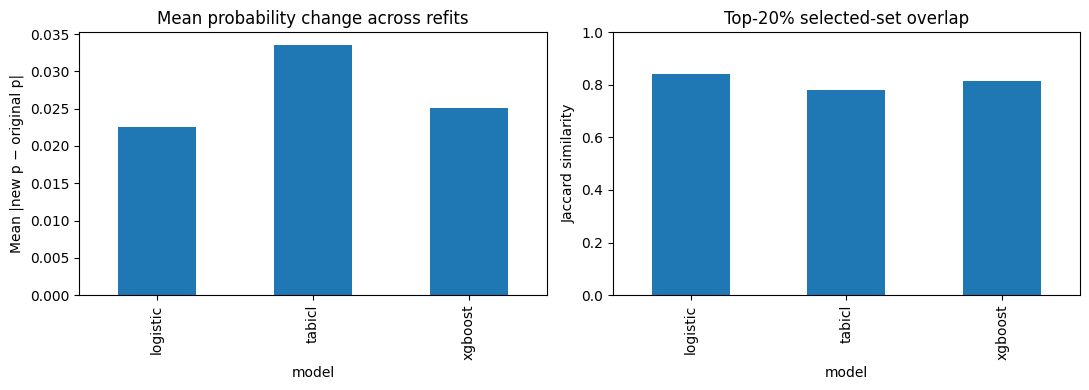

In [25]:
rng=np.random.default_rng(SEED)
stability=[]
for draw in range(3):
    sample_ix=rng.integers(0,len(X_train),len(X_train))
    xx,yy=X_train.iloc[sample_ix],y_train.iloc[sample_ix]
    modes=xx[xx.select_dtypes(exclude='number').columns].mode().iloc[0]
    for name,builder in [('logistic',make_logistic),('xgboost',make_xgboost)]:
        refit=builder(xx).fit(xx,yy)
        q=refit.predict_proba(X_eval)[:,1]
        original=probabilities[name]
        a,b=select_top(original),select_top(q)
        stability.append({'draw':draw,'model':name,'mean_abs_probability_change':np.mean(abs(q-original)),
                          'rank_correlation':pd.Series(q).corr(pd.Series(original),method='spearman'),
                          'top20_jaccard':(a&b).sum()/(a|b).sum()})
    refit=TabICLClassifier(n_estimators=16,batch_size=1,kv_cache='repr',
        checkpoint_version='tabicl-classifier-v2-20260212.ckpt',random_state=SEED,n_jobs=-1)
    refit.fit(xx.fillna(modes),yy.to_numpy())
    q=refit.predict_proba(X_eval.fillna(modes))[:,1]
    original=probabilities['tabicl']; a,b=select_top(original),select_top(q)
    stability.append({'draw':draw,'model':'tabicl','mean_abs_probability_change':np.mean(abs(q-original)),
                      'rank_correlation':pd.Series(q).corr(pd.Series(original),method='spearman'),
                      'top20_jaccard':(a&b).sum()/(a|b).sum()})
stability=pd.DataFrame(stability)
display(stability.groupby('model').agg(['mean','std']).round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
stability.groupby('model').mean_abs_probability_change.mean().plot.bar(ax=axes[0],
    title='Mean probability change across refits')
stability.groupby('model').top20_jaccard.mean().plot.bar(ax=axes[1],
    title='Top-20% selected-set overlap',ylim=(0,1))
axes[0].set_ylabel('Mean |new p − original p|'); axes[1].set_ylabel('Jaccard similarity')
plt.tight_layout(); plt.show()

## 9. Fairness at the actual support rule

At 20% capacity we compare selection rate (access), false negative rate among people later re-arrested (missed support) and false positive rate. Group gaps are descriptive and do not prove discrimination or fairness. Arrest itself is influenced by social and enforcement processes. Race and gender are audit fields only. Age is a model input, so age gaps are especially important to examine.

,model,attribute,group,n,base_rate,selection_rate,fnr,fpr
0,logistic,Gender,M,6857,0.591,0.211,0.704,0.089
1,logistic,Gender,F,950,0.454,0.117,0.800,0.048
2,logistic,Race,WHITE,3273,0.564,0.192,0.716,0.072
3,logistic,Race,BLACK,4534,0.582,0.206,0.711,0.091
4,logistic,Age_at_Release,38-42,953,0.512,0.139,0.766,0.039
5,logistic,Age_at_Release,33-37,1296,0.567,0.159,0.785,0.086
6,logistic,Age_at_Release,48 or older,1086,0.435,0.015,0.975,0.007
7,logistic,Age_at_Release,43-47,762,0.513,0.064,0.895,0.022
8,logistic,Age_at_Release,28-32,1533,0.603,0.256,0.655,0.120
9,logistic,Age_at_Release,23-27,1565,0.659,0.323,0.595,0.165


selection_rate_range  fnr_range  fpr_range
model    attribute                                                 
logistic Age_at_Release                 0.410      0.480      0.210
         Gender                         0.095      0.096      0.041
         Race                           0.014      0.005      0.019
tabicl   Age_at_Release                 0.430      0.501      0.223
         Gender                         0.107      0.121      0.041
         Race                           0.026      0.022      0.023
xgboost  Age_at_Release                 0.409      0.481      0.200
         Gender                         0.098      0.107      0.036
         Race                           0.018      0.009      0.020

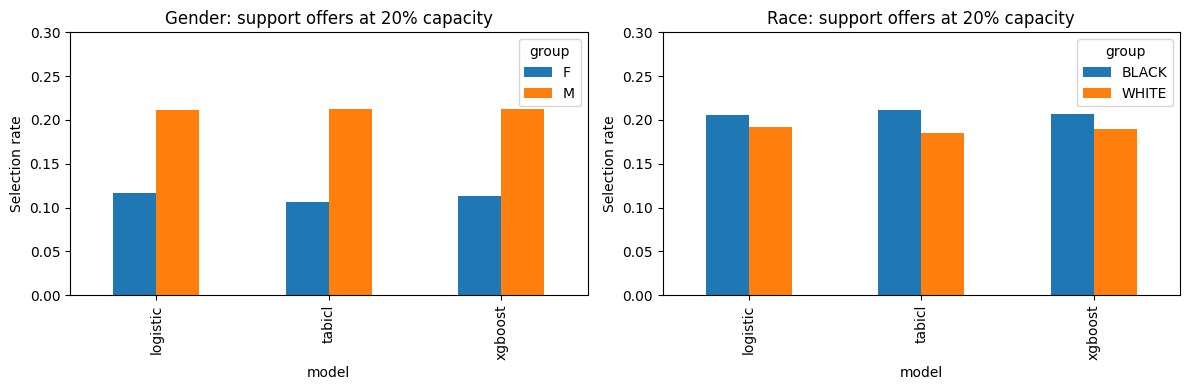

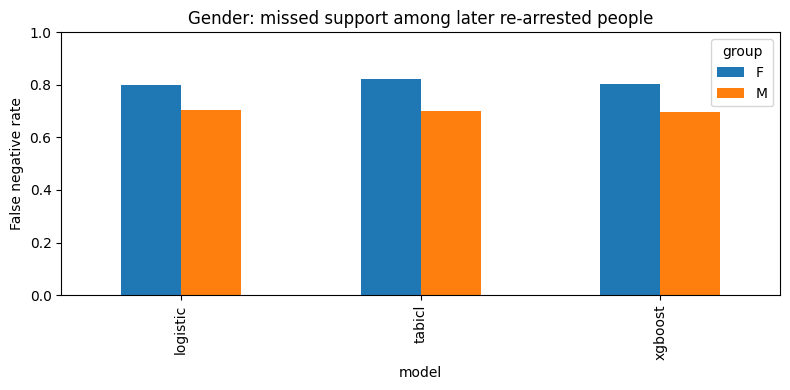

In [26]:
def group_rates(y, selected, groups, attribute, model):
    rows=[]
    for group in pd.Series(groups).fillna('Missing').unique():
        mask=np.asarray(pd.Series(groups).fillna('Missing').eq(group))
        positives=mask&(np.asarray(y)==1)
        negatives=mask&(np.asarray(y)==0)
        rows.append({'model':model,'attribute':attribute,'group':group,'n':int(mask.sum()),
                     'base_rate':np.mean(np.asarray(y)[mask]),
                     'selection_rate':selected[mask].mean(),
                     'fnr':1-selected[positives].mean() if positives.any() else np.nan,
                     'fpr':selected[negatives].mean() if negatives.any() else np.nan})
    return rows

audit_rows=[]
age=X_eval.Age_at_Release
for name,p in probabilities.items():
    chosen=select_top(p)
    audit_rows+=group_rates(y_eval,chosen,audit_eval.Gender,'Gender',name)
    audit_rows+=group_rates(y_eval,chosen,audit_eval.Race,'Race',name)
    audit_rows+=group_rates(y_eval,chosen,age,'Age_at_Release',name)
fairness=pd.DataFrame(audit_rows)
display(fairness.round(3))
gaps=fairness.groupby(['model','attribute'])[['selection_rate','fnr','fpr']].agg(
    lambda s:s.max()-s.min()).rename(columns=lambda c:c+'_range')
display(gaps.round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,attribute in zip(axes,['Gender','Race']):
    part=fairness[fairness.attribute==attribute]
    part.pivot(index='model',columns='group',values='selection_rate').plot.bar(ax=ax)
    ax.set(title=f'{attribute}: support offers at 20% capacity',ylabel='Selection rate',ylim=(0,.3))
plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(8,4))
fairness[fairness.attribute=='Gender'].pivot(index='model',columns='group',values='fnr').plot.bar(ax=ax)
ax.set(title='Gender: missed support among later re-arrested people',
       ylabel='False negative rate',ylim=(0,1))
plt.tight_layout(); plt.show()

### Test multiplicity and a training-only mitigation check

We test group differences on the published decision rule and apply Holm correction across this notebook's test family. A non-rejection does not establish equivalence. The mitigation experiment drops `Gang_Affiliated`, refits within each training fold, and scores only its held-out fold. The candidate was chosen during prior research, so this is a validation of a fixed candidate, not a fresh search over all fields.

In [27]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

tests=[]
for name,p in probabilities.items():
    chosen=select_top(p)
    for attr,groups in [('Gender',audit_eval.Gender),('Race',audit_eval.Race),
                        ('Age_at_Release',age)]:
        group=np.asarray(groups)
        for metric,mask in [('selection_rate',np.ones(len(y_eval),dtype=bool)),
                            ('fnr',y_eval.to_numpy()==1),('fpr',y_eval.to_numpy()==0)]:
            table=pd.crosstab(group[mask],chosen[mask])
            pval=chi2_contingency(table,correction=False)[1] if table.shape[0]>1 and table.shape[1]>1 else np.nan
            tests.append({'model':name,'attribute':attr,'metric':metric,'p_raw':pval})
tests=pd.DataFrame(tests)
valid=tests.p_raw.notna()
tests.loc[valid,'p_holm']=multipletests(tests.loc[valid,'p_raw'],method='holm')[1]
display(tests.round(4))
print('Holm-adjusted rejections:',int((tests.p_holm<.05).sum()),'of',int(valid.sum()))

,model,attribute,metric,p_raw,p_holm
0,logistic,Gender,selection_rate,0.0000,0.0000
1,logistic,Gender,fnr,0.0000,0.0003
2,logistic,Gender,fpr,0.0017,0.0207
3,logistic,Race,selection_rate,0.1157,0.4627
4,logistic,Race,fnr,0.7304,0.9922
5,logistic,Race,fpr,0.0492,0.2952
6,logistic,Age_at_Release,selection_rate,0.0000,0.0000
7,logistic,Age_at_Release,fnr,0.0000,0.0000
8,logistic,Age_at_Release,fpr,0.0000,0.0000
9,xgboost,Gender,selection_rate,0.0000,0.0000


Holm-adjusted rejections: 19 of 27


In [28]:
strata=y_train.astype(str)+'_'+audit_train.Gender.astype(str)
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED)
mitigation=[]
for fold,(tr,va) in enumerate(cv.split(X_train,strata),1):
    xtr,xva=X_train.iloc[tr],X_train.iloc[va]
    yy=y_train.iloc[tr]
    for name,builder in [('logistic',make_logistic),('xgboost',make_xgboost)]:
        for removed in (False,True):
            columns=[c for c in FEATURES if c!='Gang_Affiliated'] if removed else FEATURES
            model=builder(xtr[columns]).fit(xtr[columns],yy)
            p=model.predict_proba(xva[columns])[:,1]
            selected=select_top(p)
            group=audit_train.Gender.iloc[va].reset_index(drop=True)
            rates=pd.DataFrame(group_rates(y_train.iloc[va].reset_index(drop=True),selected,
                                           group,'Gender',name))
            fnr_f=float(rates.loc[rates.group=='F','fnr'].iloc[0])
            fnr_m=float(rates.loc[rates.group=='M','fnr'].iloc[0])
            mitigation.append({'fold':fold,'model':name,'drop_gang':removed,
                'auc':roc_auc_score(y_train.iloc[va],p),'female_minus_male_fnr':fnr_f-fnr_m})
mitigation=pd.DataFrame(mitigation)
display(mitigation.groupby(['model','drop_gang'])[['auc','female_minus_male_fnr']]
        .agg(['mean','std']).round(4))
print('Only training partition labels were used in this cross-validation.')

auc         female_minus_male_fnr        
                      mean     std                  mean     std
model    drop_gang                                              
logistic False      0.7326  0.0077                0.1196  0.0139
         True       0.7221  0.0068                0.0377  0.0231
xgboost  False      0.7345  0.0086                0.1280  0.0227
         True       0.7251  0.0075                0.0446  0.0374

Only training partition labels were used in this cross-validation.


### Four-dimensional comparison at a glance

The table below collects a predictive metric, an explanation-fidelity limit, a refit-stability metric and a fairness gap. It is a decision aid; these quantities have different units and should not be averaged into a single score.

In [29]:
tradeoff=metrics[['roc_auc','brier','captured_at_20pct']].copy()
tradeoff['mean_refit_top20_jaccard']=stability.groupby('model').top20_jaccard.mean()
tradeoff['gender_fnr_range']=gaps.xs('Gender',level='attribute').fnr_range
tradeoff['local_explanation_limit']=['direct coefficients' if name=='logistic'
    else ('LIME median R² ≈ '+str(round(lime_results.query("case == 'median'").local_r2.mean(),2))
          if name=='xgboost' else 'no native attribution') for name in tradeoff.index]
display(tradeoff.round(4))

,roc_auc,brier,captured_at_20pct,mean_refit_top20_jaccard,gender_fnr_range,local_explanation_limit
model,,,,,,
logistic,0.7298,0.2054,1285,0.8405,0.0964,direct coefficients
xgboost,0.7326,0.2044,1307,0.8139,0.1069,LIME median R² ≈ 0.27
tabicl,0.7328,0.2044,1293,0.7814,0.1214,no native attribution


## 10. Recommendation and limits

The primary choice is **L1 logistic regression for a prospective shadow pilot**, with XGBoost running as a challenger. XGBoost has a small but measurable ranking advantage in this retrospective evaluation and captures 12 more observed events among 1,561 offers. Logistic offers direct coefficient interpretation, simpler maintenance and greater refit stability in these resamples. TabICL has the highest point AUC but uses more compute and can only be explained from outside (PDP, ICE, LIME); exact SHAP and XPER are out of reach for it. All three models agree on the main drivers: age, prior record and gang affiliation. The median-risk person's LIME surrogate reached only about R² = 0.33, so that local rule list is a limited approximation.

The fairness gaps are material, particularly for women who are later re-arrested and across age bands. In the three training folds, dropping `Gang_Affiliated` reduced the female-minus-male FNR gap by about 0.08 but also lowered AUC by about 0.01. This is a real trade-off, not a free mitigation. The 27 tests above form this notebook's own family: TabICL's race selection-rate test survives Holm here, while none of the race tests survived correction across the broader 54-test course family in the repository audit. The conclusion is sensitive to the declared family; neither result proves race fairness. No model should allocate real services until intervention benefit, external validity, appeals, subgroup monitoring and stop rules are established. These data record arrests, not who would benefit most from help.

**Reproduction notes.** Notebook functions live above the cells that call them. The three original CSVs are embedded above, so no other repository file is needed to read or rerun this notebook. Installed public Python packages and TabICL's model checkpoint are still required; a first checkpoint download may need internet access. Numerical fit times and the final digits of XGBoost/TabICL outputs may vary by hardware and package version.

This is the end of the A–Z analysis. Every displayed chart and table above is produced by a visible executable cell in this notebook.